# 02 · The DGP zoo — realistic platform worlds (built by hand)

**NB 02** of the curriculum (`ROADMAP.md`). NB 01 used a continuous Gaussian outcome — fine for the
spine, but real platforms measure **clicks** (binary), **sessions** (counts), **revenue** (skewed,
mostly zero), **GMV-per-user** (a ratio), and **churn** (time-to-event). This notebook authors a DGP
for each — still **knowing the ground truth** (we set the potential outcomes) — and dials realism up.
These worlds become the **realism dial** every later notebook tests methods on; at the end we promote
them to a `lyra/dgp/` package.

**The one recipe (unchanged from NB 01).** Every DGP authors both potential outcomes
$\big(Y_i(0),Y_i(1)\big)$ as functions of covariates $X_i$, assigns treatment $T_i$, and reveals only
$Y_i=Y_i(T_i)$. The **true ATE** is $\tau=\mathbb E[Y(1)-Y(0)]$ — which we can always compute because
*we wrote the outcome model*, no matter how nonlinear the link.

> **The throughline to watch.** Under randomization, **difference-in-means recovers the ATE for *every*
> outcome type** — binary, count, revenue, all of it (randomization identifies $\mathbb E[Y(1)-Y(0)]$ on
> the natural scale regardless of distribution). What changes with the outcome *type* is the
> **variance / correct inference** — which is exactly why **NB 03 (metrics)** routes each metric type to
> its own variance formula. Type matters for the *error bars*, not the *point*.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import nbtools; nbtools.set_style()
from nbtools import BLUE, GREEN, PINK, ORANGE, GRAY

sig = lambda z: 1 / (1 + np.exp(-z))            # logistic link
C0, C1 = BLUE, PINK                              # control / treated colours


# small helper used all over: diff-in-means + Welch 95% CI (our NB01 estimator, one-liner)
def diff_in_means(df):
    t = df.loc[df.treat == 1, "y"].to_numpy(float); c = df.loc[df.treat == 0, "y"].to_numpy(float)
    d = t.mean() - c.mean()
    se = np.sqrt(t.var(ddof=1) / t.size + c.var(ddof=1) / c.size)
    return d, (d - 1.96 * se, d + 1.96 * se)

## 1. Binary — conversion / click (Bernoulli + logistic link)

The bread-and-butter platform metric: did the user convert? We author a **latent** linear index and
squash it through the logistic link to a probability, per arm:
$$p_w(X)=\sigma\!\big(a(X)+\beta\,w\big),\qquad Y(w)\sim\text{Bernoulli}\big(p_w(X)\big).$$
Treatment shifts the **log-odds** by $\beta$. **Crucial subtlety:** the ATE we care about is the
**risk difference** on the probability scale,
$$\tau=\mathbb E\big[p_1(X)-p_0(X)\big]\;\neq\;\beta,$$
*not* the logit coefficient $\beta$. (Other valid estimands: **risk ratio** $\mathbb E p_1/\mathbb E p_0$,
**odds ratio** $e^{\beta}$.) Because we authored $p_0,p_1$, we know $\tau$ exactly.

binary: true ATE (risk diff) = 0.1043   |   logit coef beta = 0.5 (NOT the ATE)
        diff-in-means = 0.1073  CI [0.0976, 0.1170]  -> recovers the risk difference


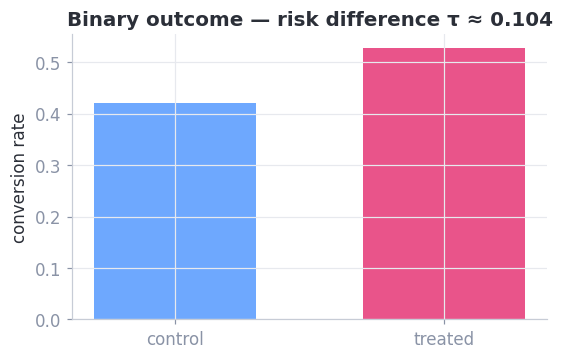

In [2]:
def sample_binary(n, seed, beta=0.5, a0=-0.4):
    rng = np.random.default_rng(seed)
    X = rng.normal(0, 1, (n, 3))
    a = a0 + 0.8 * X[:, 0] - 0.5 * X[:, 1]                 # latent baseline log-odds a(X)
    p0, p1 = sig(a), sig(a + beta)                         # per-arm conversion probabilities
    treat = (rng.random(n) < 0.5).astype(int)             # randomized A/B
    y = np.where(treat == 1, rng.random(n) < p1, rng.random(n) < p0).astype(int)
    df = pd.DataFrame({"treat": treat, "y": y})
    df[["x0", "x1", "x2"]] = X
    return df, float((p1 - p0).mean())                    # df + true risk-difference ATE

df, tau = sample_binary(40_000, seed=1, beta=0.5)
d, ci = diff_in_means(df)
print(f"binary: true ATE (risk diff) = {tau:.4f}   |   logit coef beta = 0.5 (NOT the ATE)")
print(f"        diff-in-means = {d:.4f}  CI [{ci[0]:.4f}, {ci[1]:.4f}]  -> recovers the risk difference")

fig, ax = plt.subplots(figsize=(5.2, 3.4))
ax.bar(["control", "treated"], [df[df.treat == 0].y.mean(), df[df.treat == 1].y.mean()],
       color=[C0, C1], width=.6)
ax.set_ylabel("conversion rate"); ax.set_title(f"Binary outcome — risk difference τ ≈ {tau:.3f}")
plt.tight_layout(); plt.show()

## 2. Counts — sessions / visits (Poisson)

How many sessions did the user have? Counts are non-negative integers — model with a **Poisson** (or
negative-binomial for overdispersion), **log link**:
$$\lambda_w(X)=\exp\!\big(a(X)+\beta\,w\big),\qquad Y(w)\sim\text{Poisson}\big(\lambda_w(X)\big).$$
The **rate difference** ATE is $\tau=\mathbb E[\lambda_1-\lambda_0]$; the **rate ratio** is $e^{\beta}$.
A real lever ("show more notifications") moves $\beta$.

count: true ATE (rate diff) = 0.3686   rate ratio = exp(0.15) = 1.162
       diff-in-means = 0.3632  CI [0.3231, 0.4033]


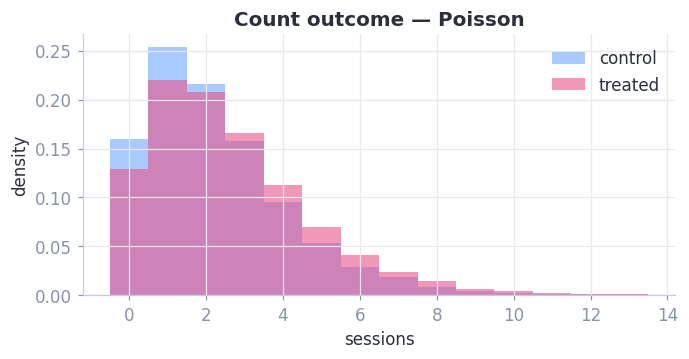

In [3]:
def sample_count(n, seed, beta=0.15, a0=0.7):
    rng = np.random.default_rng(seed)
    X = rng.normal(0, 1, (n, 3))
    a = a0 + 0.5 * X[:, 0]
    lam0, lam1 = np.exp(a), np.exp(a + beta)
    treat = (rng.random(n) < 0.5).astype(int)
    y = np.where(treat == 1, rng.poisson(lam1), rng.poisson(lam0))
    df = pd.DataFrame({"treat": treat, "y": y}); df[["x0", "x1", "x2"]] = X
    return df, float((lam1 - lam0).mean())

df, tau = sample_count(40_000, seed=1)
d, ci = diff_in_means(df)
print(f"count: true ATE (rate diff) = {tau:.4f}   rate ratio = exp(0.15) = {np.exp(0.15):.3f}")
print(f"       diff-in-means = {d:.4f}  CI [{ci[0]:.4f}, {ci[1]:.4f}]")

fig, ax = plt.subplots(figsize=(6.4, 3.4))
bins = np.arange(0, df.y.quantile(.999) + 2) - .5
ax.hist(df[df.treat == 0].y, bins=bins, density=True, alpha=.6, color=C0, label="control")
ax.hist(df[df.treat == 1].y, bins=bins, density=True, alpha=.6, color=C1, label="treated")
ax.set_xlabel("sessions"); ax.set_ylabel("density"); ax.set_title("Count outcome — Poisson"); ax.legend()
plt.tight_layout(); plt.show()

## 3. Revenue — skewed & mostly zero (spike-at-zero + lognormal)

Revenue per user is the OEC, and it's nasty: **most users spend nothing**, and spenders form a
**heavy right tail**. We author it as *convert, then spend*:
$$Y(w)=C(w)\cdot R(w),\quad C(w)\sim\text{Bernoulli}(p_w),\quad \log R(w)\sim\mathcal N(\mu_w,\sigma^2).$$
So $\mathbb E[Y(w)]=p_w\,e^{\mu_w+\sigma^2/2}$ and $\tau=\mathbb E[Y(1)]-\mathbb E[Y(0)]$. This spike-and-skew
is **why naive variance is unstable** and motivates CUPED / capping / the delta method later — diff-in-
means is still *unbiased*, just *noisy*.

revenue: share zero = 0.88   true ATE = 0.6667
         diff-in-means = 0.6094  CI [0.4964, 0.7225]  (unbiased but WIDE — heavy tail)


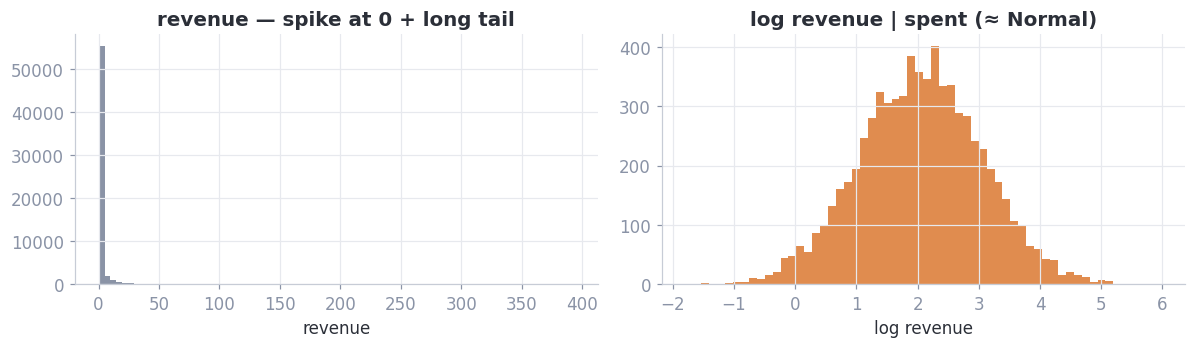

In [4]:
def sample_revenue(n, seed, dp=0.04, dmu=0.10, p0=0.10, mu0=2.0, sigma=1.0):
    rng = np.random.default_rng(seed)
    treat = (rng.random(n) < 0.5).astype(int)
    p = np.where(treat == 1, p0 + dp, p0); mu = np.where(treat == 1, mu0 + dmu, mu0)
    convert = rng.random(n) < p
    y = convert * np.exp(rng.normal(mu, sigma))
    tau = (p0 + dp) * np.exp(mu0 + dmu + sigma**2 / 2) - p0 * np.exp(mu0 + sigma**2 / 2)
    return pd.DataFrame({"treat": treat, "y": y}), float(tau)

df, tau = sample_revenue(60_000, seed=1)
d, ci = diff_in_means(df)
print(f"revenue: share zero = {(df.y == 0).mean():.2f}   true ATE = {tau:.4f}")
print(f"         diff-in-means = {d:.4f}  CI [{ci[0]:.4f}, {ci[1]:.4f}]  (unbiased but WIDE — heavy tail)")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.3))
ax[0].hist(df.y, bins=80, color=GRAY); ax[0].set_title("revenue — spike at 0 + long tail"); ax[0].set_xlabel("revenue")
spenders = df[df.y > 0]
ax[1].hist(np.log(spenders.y), bins=60, color=ORANGE); ax[1].set_title("log revenue | spent (≈ Normal)")
ax[1].set_xlabel("log revenue"); plt.tight_layout(); plt.show()

## 4. Ratio metrics — the unit mismatch (randomize by user, measure by session)

Many KPIs are **ratios** where the **randomization unit ≠ the analysis unit**: *conversion-per-session*,
*GMV-per-active-user*. Each user $i$ contributes a **random number of sessions** $m_i$ and conversions,
and the metric is the pooled ratio
$$\theta=\frac{\sum_i \text{conversions}_i}{\sum_i \text{sessions}_i}.$$
The denominator is **random**, so the naive "treat each session as iid" variance is **wrong** — this is
the **delta-method** setup (Deng–Knoblich–Lu 2018) we'll build in NB 03. Here we just author the world
and expose the per-user table both estimators will consume.

In [5]:
def sample_ratio(n_users, seed, cr0=0.20, dcr=0.02):
    rng = np.random.default_rng(seed)
    treat = (rng.random(n_users) < 0.5).astype(int)
    m = 1 + rng.poisson(4, n_users)                       # sessions per user (varies a lot)
    cr = np.where(treat == 1, cr0 + dcr, cr0)             # per-session conversion prob
    conv = rng.binomial(m, cr)                            # conversions per user
    df = pd.DataFrame({"treat": treat, "sessions": m, "conversions": conv})
    df["y"] = df.conversions / df.sessions                # per-user ratio (one way to summarise)
    return df, float(dcr)                                  # true effect on per-session conv rate

df, tau = sample_ratio(40_000, seed=1)
pooled = lambda d: d.conversions.sum() / d.sessions.sum()
theta_diff = pooled(df[df.treat == 1]) - pooled(df[df.treat == 0])
print(f"ratio: true Δ(conv/session) = {tau:.4f}")
print(f"       pooled ratio diff   = {theta_diff:.4f}   (correct point; variance needs the delta method → NB03)")
print(f"       sessions per user: mean {df.sessions.mean():.1f}, ranges {df.sessions.min()}–{df.sessions.max()}")

ratio: true Δ(conv/session) = 0.0200
       pooled ratio diff   = 0.0198   (correct point; variance needs the delta method → NB03)
       sessions per user: mean 5.0, ranges 1–17


## 5. Churn / survival — time-to-event with censoring

Retention is a **time-to-event** outcome: how long until the user churns? We author a hazard that
depends on $X$ and treatment (proportional hazards), draw event times, and **censor** at the horizon
$H$ (users still active at the end):
$$T(w)\sim\text{Exponential}\big(\lambda_w(X)\big),\ \ \lambda_w(X)=\lambda_0 e^{\,\gamma'X-\beta w},\qquad
  \text{observe }(\tilde T=\min(T,H),\ \text{event}=\mathbb 1\{T\le H\}).$$
Treatment ($\beta>0$) **lowers the hazard** → longer retention. Natural estimands: **survival at day-k**
$S_w(k)$, the **RMST** (area under $S$ up to $H$), or the **hazard ratio** $e^{-\beta}$.

survival: D30 retention  control 0.223  treated 0.367  lift +0.144


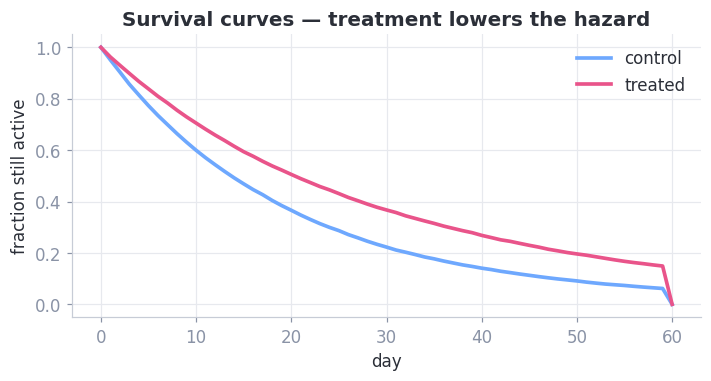

In [6]:
def sample_survival(n, seed, beta=0.4, lam0=0.05, H=60):
    rng = np.random.default_rng(seed)
    X = rng.normal(0, 1, (n, 2))
    treat = (rng.random(n) < 0.5).astype(int)
    lam = lam0 * np.exp(0.3 * X[:, 0] - beta * treat)
    T = rng.exponential(1 / lam)                          # true churn time
    obs = np.minimum(T, H); event = (T <= H).astype(int)
    df = pd.DataFrame({"treat": treat, "time": obs, "event": event})
    df["y"] = (T > 30).astype(int)                        # a simple binary OEC: retained past day 30
    return df, X, H

df, X, H = sample_survival(40_000, seed=1)
ret = df.groupby("treat").y.mean()
print(f"survival: D30 retention  control {ret[0]:.3f}  treated {ret[1]:.3f}  lift {ret[1]-ret[0]:+.3f}")

# empirical survival curve by arm = fraction whose observed time is still beyond day k
grid = np.arange(0, H + 1)
fig, ax = plt.subplots(figsize=(6.6, 3.6))
for w, col, lab in [(0, C0, "control"), (1, C1, "treated")]:
    tt = df.loc[df.treat == w, "time"].to_numpy()
    surv = [(tt > k).mean() for k in grid]
    ax.plot(grid, surv, color=col, lw=2.4, label=lab)
ax.set_xlabel("day"); ax.set_ylabel("fraction still active"); ax.set_title("Survival curves — treatment lowers the hazard")
ax.legend(); plt.tight_layout(); plt.show()

## 6. The funnel — one world, many metrics (Almedia-flavoured)

Real experiments move a **funnel**, and one DGP emits **several metrics at once** (CTR, CVR, ARPU) —
exactly the multi-metric scorecard. We compose the pieces above:
$$\text{impression}\to \text{click}\sim\text{Bern}(p_{\text{clk}})\to \text{convert}\sim\text{Bern}(p_{\text{cvr}})
  \to \text{revenue}\sim\text{lognormal}.$$
The lever (e.g. a bigger reward) lifts $p_{\text{cvr}}$ **and** spend — so each metric has its own true
ATE, and guardrails (cost) move too.

          CTR     CVR    ARPU
treat                        
0      0.3756  0.1040  1.2163
1      0.3837  0.1214  1.6661
lift   0.0081  0.0174  0.4499


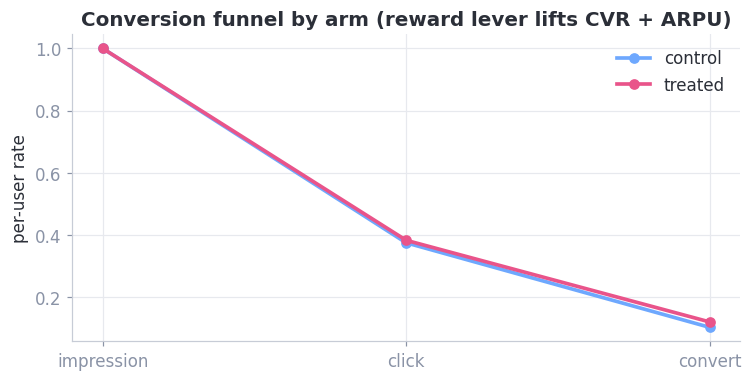

In [7]:
def sample_funnel(n, seed, d_cvr=0.03, d_logrev=0.12):
    rng = np.random.default_rng(seed)
    X = rng.normal(0, 1, (n, 3)); treat = (rng.random(n) < 0.5).astype(int)
    p_clk = sig(-0.5 + 0.4 * X[:, 0])                               # click probability
    p_cvr = np.clip(sig(-1.0 + 0.5 * X[:, 1]) + d_cvr * treat, 0, 1)  # treated lifts conversion (prob scale)
    click = rng.random(n) < p_clk
    convert = click & (rng.random(n) < p_cvr)                       # must click before converting
    revenue = convert * np.exp(rng.normal(2.0 + d_logrev * treat, 1.0))
    return pd.DataFrame({"treat": treat, "click": click.astype(int),
                         "convert": convert.astype(int), "revenue": revenue})

f = sample_funnel(80_000, seed=1)
g = f.groupby("treat").agg(CTR=("click", "mean"), CVR=("convert", "mean"), ARPU=("revenue", "mean"))
g.loc["lift"] = g.loc[1] - g.loc[0]
print(g.round(4).to_string())

fig, ax = plt.subplots(figsize=(7, 3.6))
stages = ["impression", "click", "convert"]
for w, col, lab in [(0, C0, "control"), (1, C1, "treated")]:
    sub = f[f.treat == w]
    vals = [1.0, sub.click.mean(), sub.convert.mean()]
    ax.plot(stages, vals, "-o", color=col, lw=2.4, label=lab)
ax.set_ylabel("per-user rate"); ax.set_title("Conversion funnel by arm (reward lever lifts CVR + ARPU)")
ax.legend(); plt.tight_layout(); plt.show()

## 7. Staggered-entry panel — for peeking & DiD (Sant'Anna–Zhao flavour)

Sequential testing (NB 07) and difference-in-differences (NB 11) need **time**: units observed over
periods, **entering treatment at different times** (staggered adoption), with **selection on $X$** and a
**time trend**. This ports the structure of Daniel's own `paper-library/monte_carlo_did_cov.qmd`
(Sant'Anna–Zhao 2020 DGP 1):
$$Y_{it}=f(X_i)+\underbrace{\theta_t}_{\text{calendar trend}}+\underbrace{\eta_i}_{\text{unit fixed effect}}
  +\;\text{ATT}\cdot \mathbb 1\{t\ge G_i\}\,D_i+\varepsilon_{it},$$
where the adoption period $G_i$ is **later for some cohorts** and the *eventually-treated* group is
selected via a propensity in $X$. The known **ATT** is what DiD must recover — and note **diff-in-means
is biased here** (treated cohorts differ at baseline + the trend), which is exactly why we need DiD.

panel: true ATT = 1.00   |   naive last-period diff = 1.84  (BIASED: selection + trend → needs DiD)


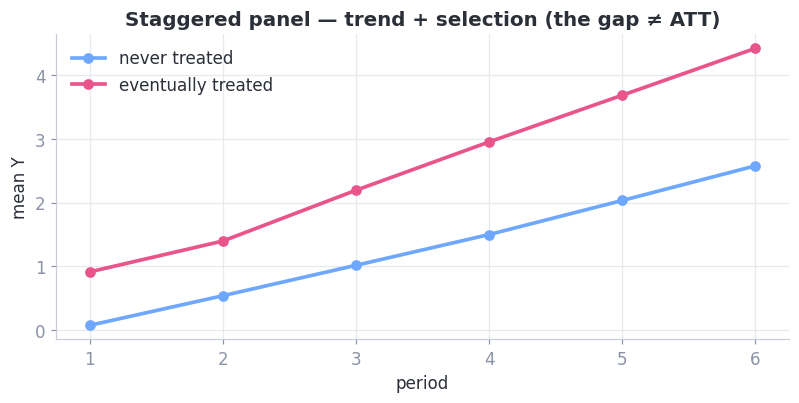

In [8]:
def sample_panel(n, seed, T=6, att=1.0, xi_ps=0.75):
    rng = np.random.default_rng(seed)
    X = rng.normal(0, 1, (n, 4))
    fx = X @ np.array([1.0, -0.5, 0.3, 0.2])                         # covariate index (drives Y and selection)
    treated = (rng.random(n) < sig(xi_ps * fx)).astype(int)         # selection on X (eventually-treated)
    G = np.where(treated == 1, rng.integers(3, T + 1, n), 10**6)    # staggered adoption period (∞ = never)
    eta = fx + rng.normal(0, 1, n)                                  # unit fixed effect (correlated with X)
    rows = []
    for t in range(1, T + 1):
        post = (t >= G).astype(int)
        y = eta + 0.5 * t + att * post + rng.normal(0, 1, n)        # trend 0.5·t + ATT on the treated-post
        rows.append(pd.DataFrame({"unit": np.arange(n), "period": t, "treated_group": treated,
                                  "G": G, "post": post, "y": y}))
    return pd.concat(rows, ignore_index=True), float(att)

panel, att = sample_panel(6000, seed=1)
# naive cross-section diff-in-means at the last period (treated_group vs not) — biased
last = panel[panel.period == panel.period.max()]
naive = last[last.treated_group == 1].y.mean() - last[last.treated_group == 0].y.mean()
print(f"panel: true ATT = {att:.2f}   |   naive last-period diff = {naive:.2f}  (BIASED: selection + trend → needs DiD)")

# event-study-style means by cohort-relative time
fig, ax = plt.subplots(figsize=(7.4, 3.8))
for w, col, lab in [(0, C0, "never treated"), (1, C1, "eventually treated")]:
    m = panel[panel.treated_group == w].groupby("period").y.mean()
    ax.plot(m.index, m.values, "-o", color=col, lw=2.4, label=lab)
ax.set_xlabel("period"); ax.set_ylabel("mean Y"); ax.set_title("Staggered panel — trend + selection (the gap ≠ ATT)")
ax.legend(); plt.tight_layout(); plt.show()

## 8. The zoo, and the promotion

We now have authored, **ground-truth-known** worlds spanning the realism dial: **binary · count ·
revenue · ratio · survival · funnel · staggered panel**. Two lessons to carry forward:

1. **Identification is type-agnostic:** under randomization, diff-in-means recovered the ATE in *every*
   world (binary, count, revenue, …). The outcome **type drives the variance / inference**, not the
   point — the motivation for the **typed metric layer in NB 03**.
2. **Time + selection break diff-in-means** (the panel) — motivating sequential methods (NB 07) and DiD
   (NB 11), where the `monte_carlo_did_cov.qmd` recipe returns.

## 9. Promote — lift the zoo into `lyra/dgp/`

Now we extract these into a **`lyra/dgp/` package** — `outcomes.py` (binary/count/revenue/ratio/
survival), `funnel.py`, `panel.py` — each a `DGP` with `sample()` + `ground_truth()`. The truth is
computed from the **expected** potential outcomes on a large oracle sample (not a single noisy draw),
so the harness from NB 01 can certify estimators against the *right* truth per world.

In [9]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from lyra.dgp import BinaryDGP, CountDGP, RevenueDGP, RatioDGP, SurvivalDGP, FunnelDGP, StaggeredPanelDGP
from lyra.estimators import DiffInMeans
from lyra.harness import harness

for dgp in [BinaryDGP(), CountDGP(), RevenueDGP(), SurvivalDGP(), FunnelDGP()]:
    r = harness(DiffInMeans(), dgp, R=120, n=25000)
    print(f"  {dgp.name:9s} oracle truth {r['truth']:+.4f}   diff-in-means bias {r['bias']:+.4f}   coverage {r['coverage']:.2f}")
print(f"  ratio     truth {RatioDGP().ground_truth().ate:+.4f}  (pooled-ratio / delta method in NB 03)")
print(f"  panel     ATT   {StaggeredPanelDGP().ground_truth().ate:+.4f}  (naive biased → DiD in NB 11)")

  binary    oracle truth +0.1044   diff-in-means bias +0.0007   coverage 0.96


  count     oracle truth +0.3691   diff-in-means bias +0.0010   coverage 0.98
  revenue   oracle truth +0.6667   diff-in-means bias +0.0012   coverage 0.94


  survival  oracle truth +0.1359   diff-in-means bias +0.0009   coverage 0.97


  funnel    oracle truth +0.3232   diff-in-means bias -0.0065   coverage 0.93
  ratio     truth +0.0200  (pooled-ratio / delta method in NB 03)
  panel     ATT   +1.0000  (naive biased → DiD in NB 11)


✅ **Promoted** (and covered by `tests/test_dgp_zoo.py`). A subtle lesson surfaced here: the funnel's
true ARPU lift is **≈ 0.32**, not the **0.45** the *single* sample in §6 printed — the heavy revenue
tail makes one draw noisy, which is exactly why `ground_truth()` uses a large **oracle** sample. This
is the payoff of authoring the DGP: the truth is a computed quantity, not a guess from one experiment.

**Next (per `ROADMAP.md`): NB 03 — metrics**, which consumes these worlds: binary → two-proportion z,
ratio → delta method, revenue → CUPED / capping. (NB 04 — cluster-robust SEs — is queued with its
references annotated.)